# VGG16 - CLAHE + Two stage preprocessing
- ugyan az a VGG16 halo, optimalizalt thresholdal
- CLAHE marad
- az U-netet levaltom egyszeru asszimetrikus center-cropp-ra
- mivel az U-net neuralis halonal is fennt allt a domain shift problema, ezert robosztusabb megoldas kell
- kb behatarolom, hol lehet a tudo es a felesleges reszeket levagva nagyjabol csak a tudot meghagyva dolgozom fel a kepeket
- ennek a halonak a tanitasara egy teljesen mas datasetet fogok alkalmazni, hogy letesztelhessem a cross-dataset jelenseget
- az elozo halo mas dataseten tanult, viszont ennek a halonak a datasetjen lesz tesztelve es kiertekelve es forditva

**Importok**

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
 
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
 
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
 
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Konfiguracio**

In [6]:
# a COVID-19 Radiography Database flat strukturaju:
# /COVID-19_Radiography_Dataset/
#     Normal/images/
#     Viral Pneumonia/images/
 
DATASET_DIR = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
NORMAL_DIR    = os.path.join(DATASET_DIR, "Normal", "images")
PNEUMONIA_DIR = os.path.join(DATASET_DIR, "Viral Pneumonia", "images")
 
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_INITIAL = 20
EPOCHS_FINE = 40
SEED = 42
 
OUT_ROOT   = "/kaggle/working"
FIG_DIR    = os.path.join(OUT_ROOT, "figures")
MET_DIR    = os.path.join(OUT_ROOT, "metrics")
MODEL_DIR  = os.path.join(OUT_ROOT, "models")

In [8]:
# mivel nincs elore felosztott train/val/test struktura,
# a kepek listajabol DataFrame-et epitunk, majd 80/10/10 aranyban osztjuk fel
 
normal_files    = [os.path.join(NORMAL_DIR, f)    for f in os.listdir(NORMAL_DIR)    if f.lower().endswith((".png", ".jpg", ".jpeg"))]
pneumonia_files = [os.path.join(PNEUMONIA_DIR, f) for f in os.listdir(PNEUMONIA_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
 
print(f"Normal képek száma:    {len(normal_files)}")
print(f"Pneumonia képek száma: {len(pneumonia_files)}")
 
df = pd.DataFrame({
    "filepath": normal_files + pneumonia_files,
    "label":    ["NORMAL"] * len(normal_files) + ["PNEUMONIA"] * len(pneumonia_files)
})
 
df_train, df_temp = train_test_split(df, test_size=0.20, random_state=SEED, stratify=df["label"])
df_val,   df_test = train_test_split(df_temp, test_size=0.50, random_state=SEED, stratify=df_temp["label"])
 
print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print(df_train["label"].value_counts())

Normal képek száma:    10192
Pneumonia képek száma: 1345
Train: 9229 | Val: 1154 | Test: 1154
label
NORMAL       8153
PNEUMONIA    1076
Name: count, dtype: int64


**CLAHE + Center cropp**

In [9]:
# --- ASZIMMETRIKUS CENTER CROP + CLAHE PREPROCESSING ---
# tudorontgennel a tudo kb mindig kozepen helyezkedik el
# asszimetrikus cropp -> felulrol kicsit tobbet vagunk le
# (nyak/vall), alul e soldal kevesebbet -> determinisztikus
# es nem tud felremenni idegen kepeken sem

#hangolhato parameterek
CROP_TOP    = 0.15
CROP_BOTTOM = 0.90
CROP_LEFT   = 0.05
CROP_RIGHT  = 0.95
 
def crop_clahe(img):
    img_uint8 = np.clip(img, 0, 255).astype('uint8')
    h, w = img_uint8.shape[:2]
 
    y1 = int(h * CROP_TOP)
    y2 = int(h * CROP_BOTTOM)
    x1 = int(w * CROP_LEFT)
    x2 = int(w * CROP_RIGHT)
 
    cropped = img_uint8[y1:y2, x1:x2]
    cropped = cv2.resize(cropped, (224, 224))
 
    lab = cv2.cvtColor(cropped, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
 
    return preprocess_input(final_img.astype('float32'))

**Adatgeneratorok - VGG specifikus preprocess input**

In [10]:
train_datagen = ImageDataGenerator(
    preprocessing_function=crop_clahe,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=False
)
 
val_test_datagen = ImageDataGenerator(
    preprocessing_function=crop_clahe
)
 
train_gen = train_datagen.flow_from_dataframe(
    df_train,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=SEED
)
 
val_gen = val_test_datagen.flow_from_dataframe(
    df_val,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
 
test_gen = val_test_datagen.flow_from_dataframe(
    df_test,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
 
print("Class indices:", train_gen.class_indices)

Found 9229 validated image filenames belonging to 2 classes.
Found 1154 validated image filenames belonging to 2 classes.
Found 1154 validated image filenames belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


**Class weight**

In [11]:
counts = np.bincount(train_gen.classes)
total  = counts.sum()
class_weight = {0: total / (2 * counts[0]), 1: total / (2 * counts[1])}
print("Train class counts:", counts, "| class_weight:", class_weight)

Train class counts: [8153 1076] | class_weight: {0: np.float64(0.5659879798847051), 1: np.float64(4.288568773234201)}


**Modell-VGG16**

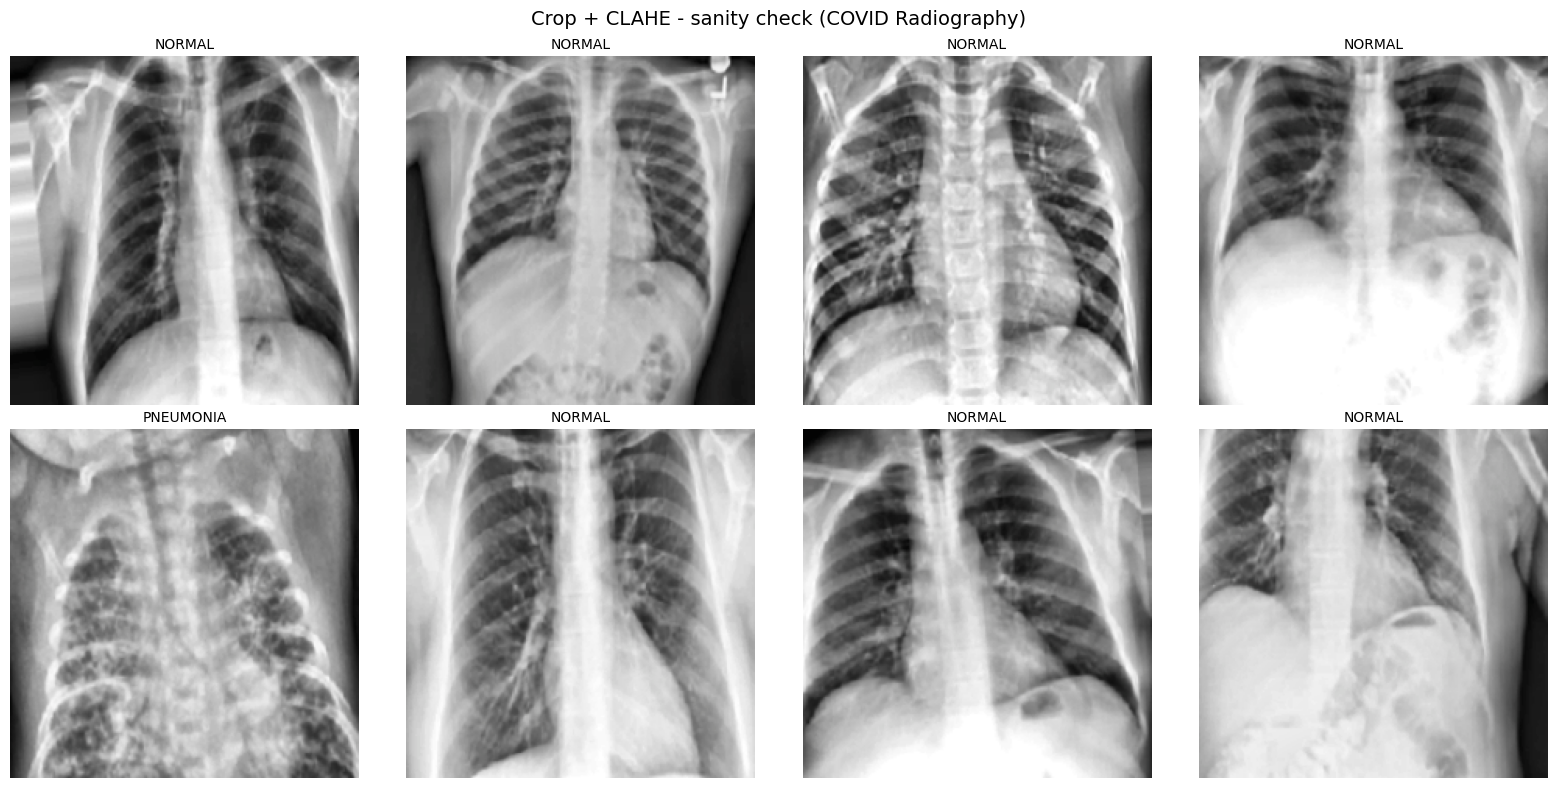

Saved: /kaggle/working/figures/preprocessing_sanity_check.png


I0000 00:00:1778165142.870919      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           51

 Total params: 14,979,905 (57.14 MB)

 Trainable params: 264,193 (1.01 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [12]:
# --- SANITY CHECK: nehany preprocesszalt kep vizualis megjelintese ---
# tanitas elott ellenorizni kell hogy jol mukodik e a preprocessing
def visualize_preprocessing(gen, n=8, title="Preprocessing sanity check"):
    gen.reset()
    batch_imgs, batch_labels = next(gen)
    idx_to_class = {v: k for k, v in gen.class_indices.items()}
 
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
    plt.suptitle(title, fontsize=14)
 
    for i in range(min(n, len(batch_imgs))):
        img = batch_imgs[i].copy()
        img[..., 0] += 103.939
        img[..., 1] += 116.779
        img[..., 2] += 123.68
        img = img[..., ::-1]
        img = np.clip(img, 0, 255).astype('uint8')
 
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(idx_to_class[int(batch_labels[i])], fontsize=10)
        plt.axis("off")
 
    plt.tight_layout()
    sanity_path = os.path.join(FIG_DIR, "preprocessing_sanity_check.png")
    plt.savefig(sanity_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", sanity_path)
    gen.reset()
 
visualize_preprocessing(train_gen, n=8, title="Crop + CLAHE - sanity check (COVID Radiography)")
 
base = VGG16(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(224, 224, 3))
)
 
for layer in base.layers:
    layer.trainable = False
 
x = GlobalAveragePooling2D()(base.output)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
out = Dense(1, activation='sigmoid')(x)
 
model = Model(inputs=base.inputs, outputs=out)
 
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
 
model.summary()

**Callbackek**

In [14]:
ckpt_path = os.path.join(MODEL_DIR, "vgg16_best.keras")
 
callbacks1 = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True)
]

**Phase 1 - Training**

In [15]:
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_INITIAL,
    callbacks=callbacks1,
    class_weight=class_weight
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1778165262.473987     138 service.cc:152] XLA service 0x7bc1e000dd40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778165262.474051     138 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778165263.300266     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/289 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - accuracy: 0.3672 - loss: 0.8504 

I0000 00:00:1778165272.159333     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


289/289 ━━━━━━━━━━━━━━━━━━━━ 295s 982ms/step - accuracy: 0.6957 - loss: 0.4318 - val_accuracy: 0.9575 - val_loss: 0.1067 - learning_rate: 1.0000e-04
Epoch 2/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 195s 674ms/step - accuracy: 0.9302 - loss: 0.1588 - val_accuracy: 0.9593 - val_loss: 0.0915 - learning_rate: 1.0000e-04
Epoch 3/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 194s 670ms/step - accuracy: 0.9459 - loss: 0.1227 - val_accuracy: 0.9645 - val_loss: 0.0826 - learning_rate: 1.0000e-04
Epoch 4/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 197s 680ms/step - accuracy: 0.9535 - loss: 0.1174 - val_accuracy: 0.9809 - val_loss: 0.0578 - learning_rate: 1.0000e-04
Epoch 5/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 195s 673ms/step - accuracy: 0.9569 - loss: 0.1076 - val_accuracy: 0.9757 - val_loss: 0.0596 - learning_rate: 1.0000e-04
Epoch 6/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 193s 667ms/step - accuracy: 0.9572 - loss: 0.0892 - val_accuracy: 0.9705 - val_loss: 0.0651 - learning_rate: 1.0000e-04
Epoch 7/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 194s 672ms/

**Fine-Tuning**
- VGG16-nal erdemes csak a block5-ot engedni

In [16]:
for layer in base.layers:
    layer.trainable = "block5" in layer.name
 
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
 
callbacks2 = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True)
]
 
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    callbacks=callbacks2,
    class_weight=class_weight
)

Epoch 1/40
289/289 ━━━━━━━━━━━━━━━━━━━━ 204s 683ms/step - accuracy: 0.9707 - loss: 0.0758 - val_accuracy: 0.9896 - val_loss: 0.0256 - learning_rate: 1.0000e-05
Epoch 2/40
289/289 ━━━━━━━━━━━━━━━━━━━━ 192s 663ms/step - accuracy: 0.9724 - loss: 0.0664 - val_accuracy: 0.9835 - val_loss: 0.0526 - learning_rate: 1.0000e-05
Epoch 3/40
289/289 ━━━━━━━━━━━━━━━━━━━━ 193s 667ms/step - accuracy: 0.9787 - loss: 0.0563 - val_accuracy: 0.9913 - val_loss: 0.0232 - learning_rate: 1.0000e-05
Epoch 4/40
289/289 ━━━━━━━━━━━━━━━━━━━━ 197s 681ms/step - accuracy: 0.9810 - loss: 0.0468 - val_accuracy: 0.9948 - val_loss: 0.0211 - learning_rate: 1.0000e-05
Epoch 5/40
289/289 ━━━━━━━━━━━━━━━━━━━━ 194s 672ms/step - accuracy: 0.9848 - loss: 0.0405 - val_accuracy: 0.9835 - val_loss: 0.0457 - learning_rate: 1.0000e-05
Epoch 6/40
289/289 ━━━━━━━━━━━━━━━━━━━━ 194s 671ms/step - accuracy: 0.9790 - loss: 0.0441 - val_accuracy: 0.9853 - val_loss: 0.0451 - learning_rate: 1.0000e-05
Epoch 7/40
289/289 ━━━━━━━━━━━━━━━━━━━━ 

**Grafikonok**

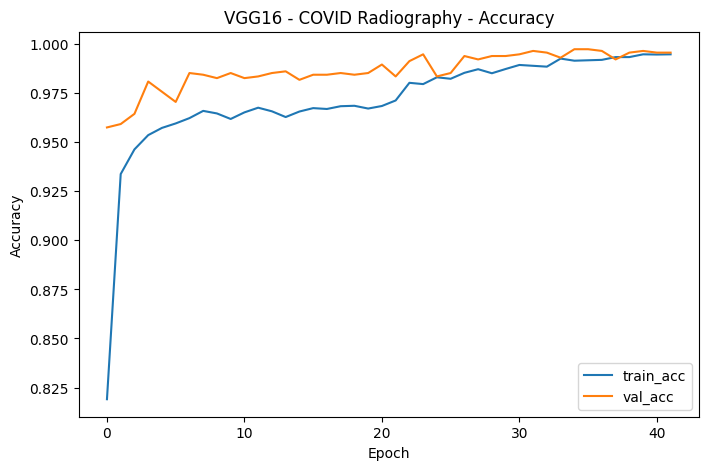

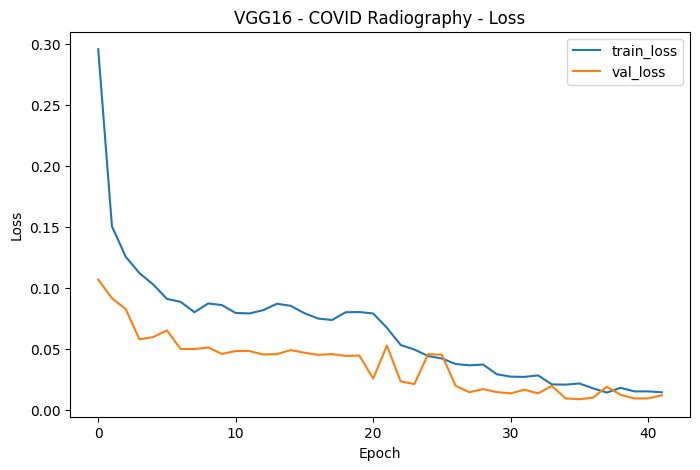

Saved: /kaggle/working/figures/vgg16_covid_accuracy.png
Saved: /kaggle/working/figures/vgg16_covid_loss.png


In [17]:
def merge_histories(h1, h2):
    merged = {}
    for k in h1.history.keys():
        merged[k] = h1.history[k] + h2.history[k]
    return merged
 
hist = merge_histories(history1, history2)
 
plt.figure(figsize=(8, 5))
plt.plot(hist["accuracy"], label="train_acc")
plt.plot(hist["val_accuracy"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 - COVID Radiography - Accuracy")
plt.legend()
acc_path = os.path.join(FIG_DIR, "vgg16_covid_accuracy.png")
plt.savefig(acc_path, dpi=150, bbox_inches="tight")
plt.show()
 
plt.figure(figsize=(8, 5))
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG16 - COVID Radiography - Loss")
plt.legend()
loss_path = os.path.join(FIG_DIR, "vgg16_covid_loss.png")
plt.savefig(loss_path, dpi=150, bbox_inches="tight")
plt.show()
 
print("Saved:", acc_path)
print("Saved:", loss_path)

**Kiertekeles+JSON mentes**

Threshold | Accuracy | Sensitivity | Specificity
0.30       | 0.9861   | 0.9328     | 0.9931
0.35       | 0.9861   | 0.9328     | 0.9931
0.40       | 0.9870   | 0.9328     | 0.9941
0.45       | 0.9861   | 0.9254     | 0.9941
0.50       | 0.9861   | 0.9254     | 0.9941
0.55       | 0.9870   | 0.9254     | 0.9951
0.60       | 0.9870   | 0.9179     | 0.9961
0.65       | 0.9879   | 0.9179     | 0.9971
0.70       | 0.9887   | 0.9179     | 0.9980
0.75       | 0.9887   | 0.9179     | 0.9980
0.80       | 0.9896   | 0.9179     | 0.9990


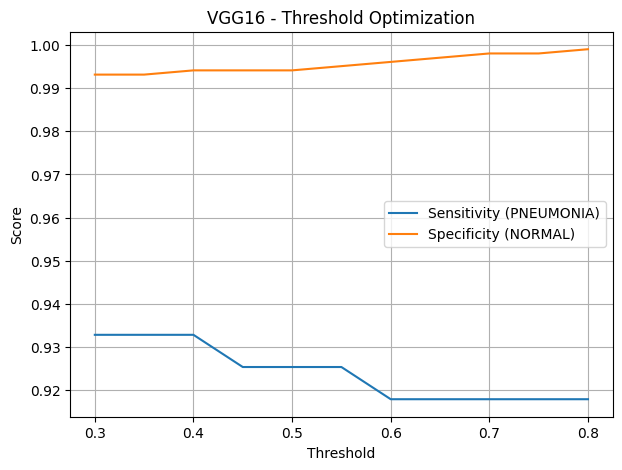

              precision    recall  f1-score   support

      NORMAL       0.99      0.99      0.99      1020
   PNEUMONIA       0.95      0.93      0.94       134

    accuracy                           0.99      1154
   macro avg       0.97      0.96      0.97      1154
weighted avg       0.99      0.99      0.99      1154



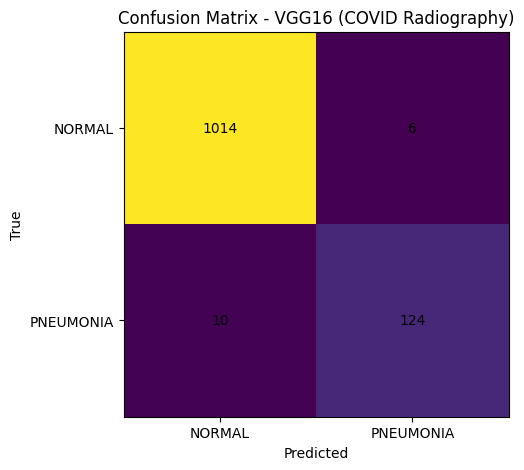

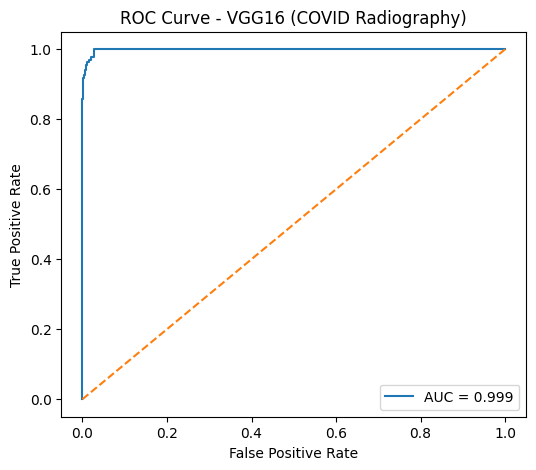

Saved: /kaggle/working/figures/vgg16_covid_confusion_matrix.png
Saved: /kaggle/working/figures/vgg16_covid_roc.png
Saved: /kaggle/working/metrics/vgg16_crop_clahe_covid_radiography_metrics.json


In [18]:
model.load_weights(ckpt_path)
 
test_gen.reset()
y_prob = model.predict(test_gen, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes
 
thresholds = np.arange(0.3, 0.81, 0.05)
results = []
 
for th in thresholds:
    y_pred_th = (y_prob >= th).astype(int)
    cm_th = confusion_matrix(y_true, y_pred_th)
    tn, fp, fn, tp = cm_th.ravel()
    results.append((
        th,
        accuracy_score(y_true, y_pred_th),
        tp / (tp + fn),
        tn / (tn + fp)
    ))
 
print("Threshold | Accuracy | Sensitivity | Specificity")
for r in results:
    print(f"{r[0]:.2f}       | {r[1]:.4f}   | {r[2]:.4f}     | {r[3]:.4f}")
 
plt.figure(figsize=(7, 5))
plt.plot([r[0] for r in results], [r[2] for r in results], label="Sensitivity (PNEUMONIA)")
plt.plot([r[0] for r in results], [r[3] for r in results], label="Specificity (NORMAL)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("VGG16 - Threshold Optimization")
plt.legend()
plt.grid(True)
plt.show()
 
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))
 
report = classification_report(
    y_true, y_pred,
    target_names=["NORMAL", "PNEUMONIA"],
    output_dict=True
)
 
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5.5, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - VGG16 (COVID Radiography)")
plt.xticks([0, 1], ["NORMAL", "PNEUMONIA"])
plt.yticks([0, 1], ["NORMAL", "PNEUMONIA"])
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
cm_path = os.path.join(FIG_DIR, "vgg16_covid_confusion_matrix.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
 
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - VGG16 (COVID Radiography)")
plt.legend()
roc_path = os.path.join(FIG_DIR, "vgg16_covid_roc.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()
 
metrics_out = {
    "model": "VGG16_transfer_COVID_Radiography",
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_total": len(hist["loss"]),
    "roc_auc": float(roc_auc),
    "confusion_matrix": cm.tolist(),
    "classification_report": report
}
 
met_path = os.path.join(MET_DIR, "vgg16_crop_clahe_covid_radiography_metrics.json")
with open(met_path, "w") as f:
    json.dump(metrics_out, f, indent=2)
 
print("Saved:", cm_path)
print("Saved:", roc_path)
print("Saved:", met_path)

**Modell save**

In [19]:
final_model_path = os.path.join(MODEL_DIR, "vgg16_covid_radiography_final.keras")
model.save(final_model_path)
print("Saved:", final_model_path)

Saved: /kaggle/working/models/vgg16_covid_radiography_final.keras


**Random predikciok**

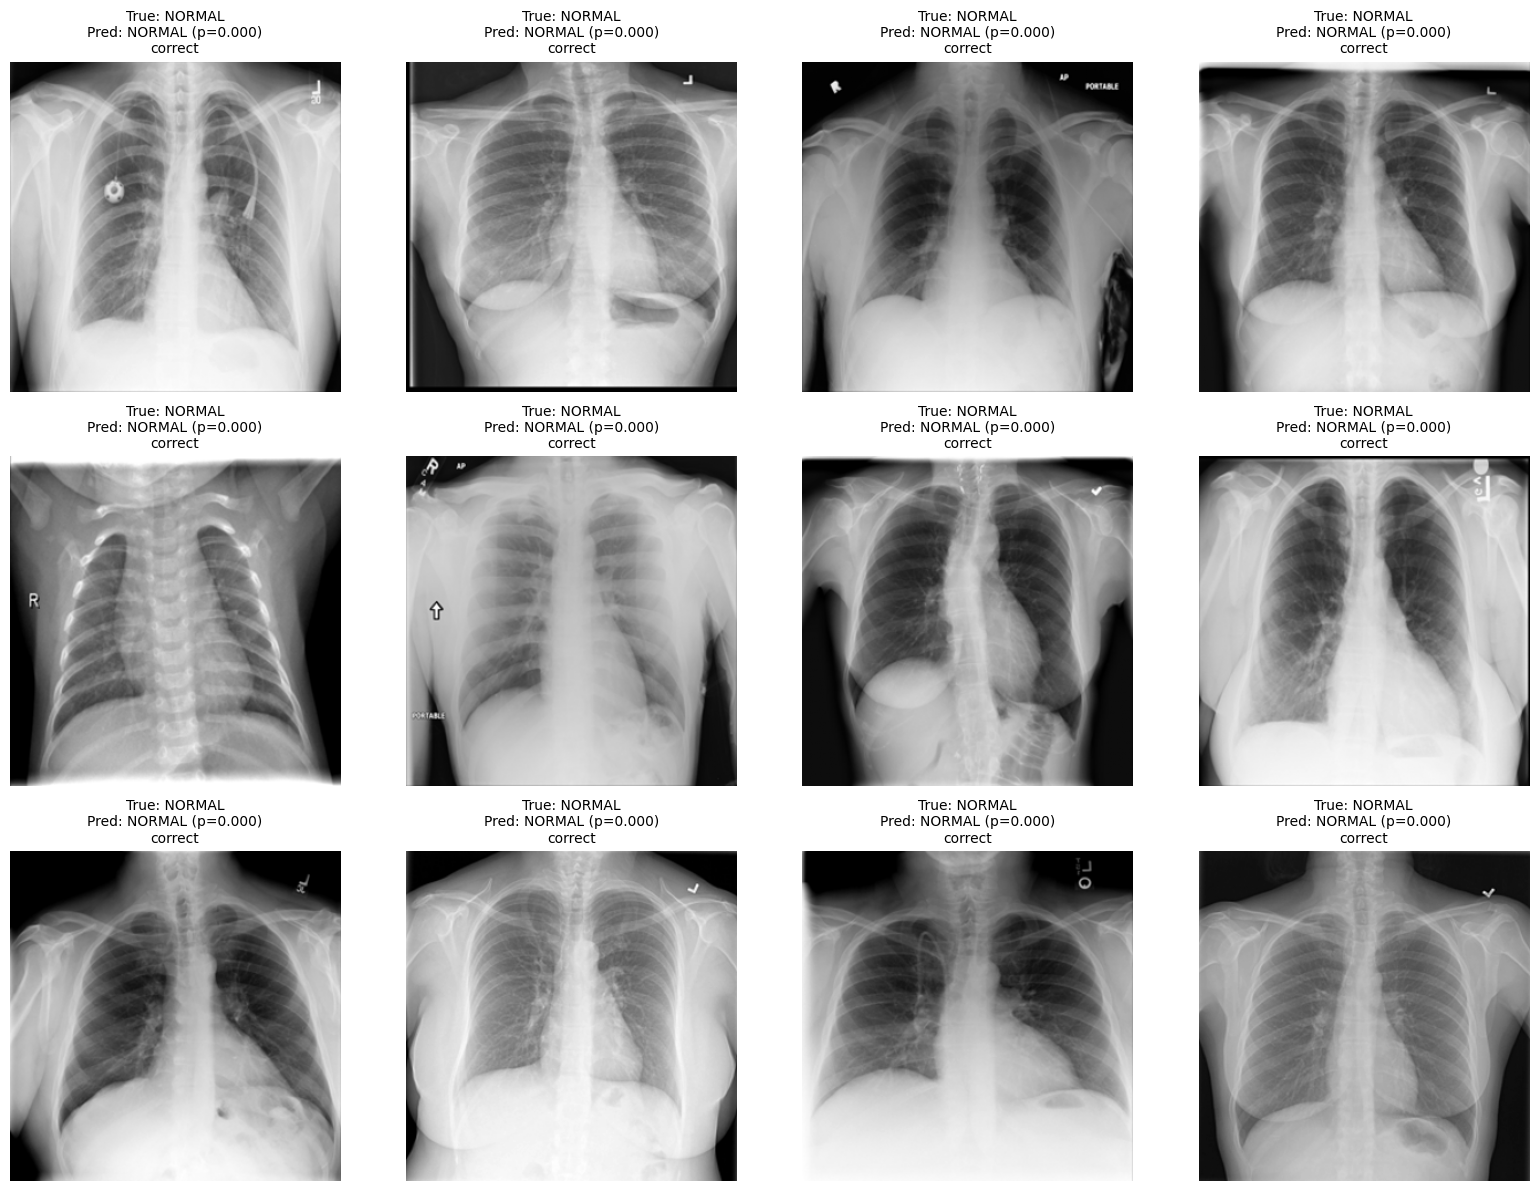

In [20]:
def show_predictions_grid(model, test_gen, n=12, threshold=0.5, seed=42):
    rng = np.random.default_rng(seed)
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=0).ravel()
    y_true = test_gen.classes
    y_pred = (y_prob >= threshold).astype(int)
    idxs = rng.choice(len(y_true), size=min(n, len(y_true)), replace=False)
    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
    class_names = [idx_to_class[0], idx_to_class[1]]
 
    cols = 4
    rows = int(np.ceil(len(idxs) / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
 
    for i, idx in enumerate(idxs, start=1):
        img = plt.imread(test_gen.filenames[idx] if hasattr(test_gen, 'filenames') else test_gen.filepaths[idx])
        true_label  = y_true[idx]
        pred_label  = y_pred[idx]
        prob        = y_prob[idx]
        correct     = (true_label == pred_label)
        title = (
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]} (p={prob:.3f})\n"
            f"{'correct' if correct else 'wrong'}"
        )
        plt.subplot(rows, cols, i)
        plt.imshow(img, cmap="gray" if img.ndim == 2 else None)
        plt.axis("off")
        plt.title(title, fontsize=10)
 
    plt.tight_layout()
    plt.show()
 
show_predictions_grid(model, test_gen, n=12, threshold=0.5, seed=42)

**Top hibak**

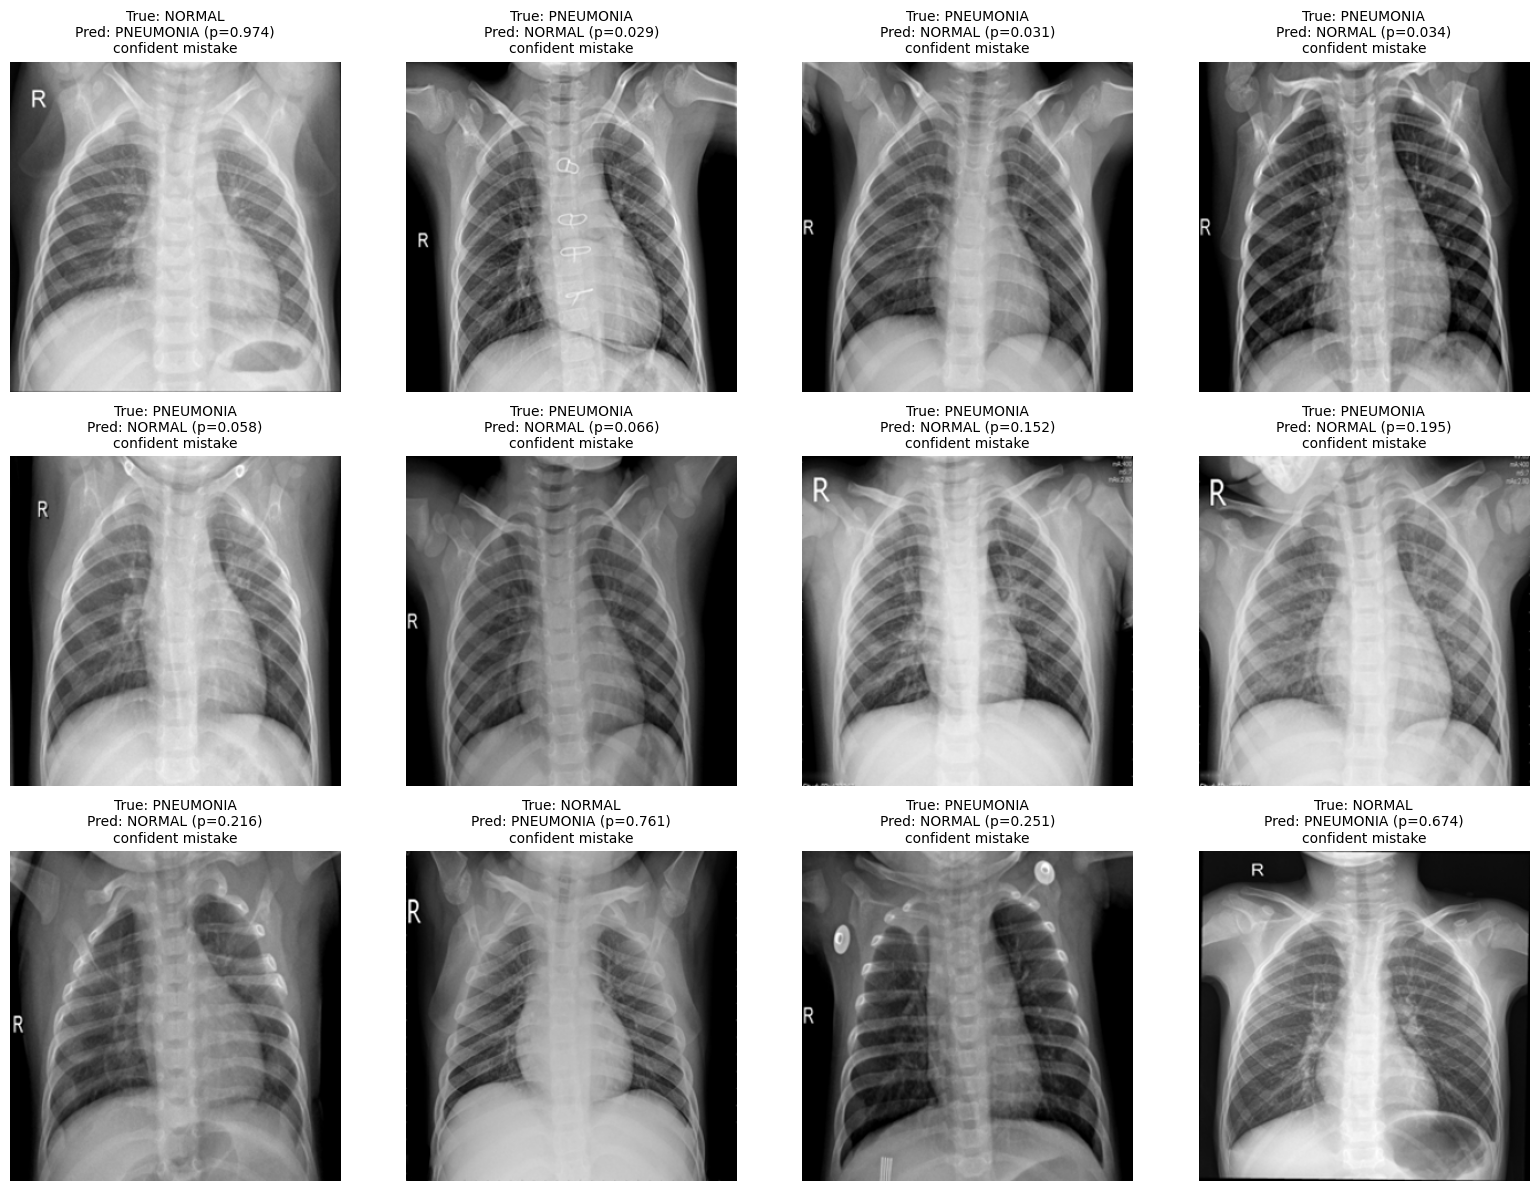

In [21]:
def show_top_mistakes(model, test_gen, k=12, threshold=0.5):
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=0).ravel()
    y_true = test_gen.classes
    y_pred = (y_prob >= threshold).astype(int)
 
    wrong = np.where(y_true != y_pred)[0]
    if len(wrong) == 0:
        print("No mistakes on the test set with this threshold.")
        return
 
    confidence  = np.abs(y_prob[wrong] - threshold)
    top_wrong   = wrong[np.argsort(-confidence)][:min(k, len(wrong))]
    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
    class_names  = [idx_to_class[0], idx_to_class[1]]
 
    cols = 4
    rows = int(np.ceil(len(top_wrong) / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
 
    for i, idx in enumerate(top_wrong, start=1):
        img = plt.imread(test_gen.filenames[idx] if hasattr(test_gen, 'filenames') else test_gen.filepaths[idx])
        true_label = y_true[idx]
        pred_label = y_pred[idx]
        prob       = y_prob[idx]
        title = (
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]} (p={prob:.3f})\n"
            f"confident mistake"
        )
        plt.subplot(rows, cols, i)
        plt.imshow(img, cmap="gray" if img.ndim == 2 else None)
        plt.axis("off")
        plt.title(title, fontsize=10)
 
    plt.tight_layout()
    plt.show()
 
show_top_mistakes(model, test_gen, k=12, threshold=0.5)

**Grad-CAM**

In [22]:
def find_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found")
 
last_conv_name = find_last_conv_layer_name(model)
print("Last conv layer:", last_conv_name)

Last conv layer: block5_conv3


In [23]:
def make_gradcam_heatmap(img_batch, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_batch, training=False)
        score = preds[:, 0]
    grads       = tape.gradient(score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))
    conv_out     = conv_out[0]
    pooled_grads = pooled_grads[0]
    heatmap      = tf.reduce_sum(conv_out * pooled_grads, axis=-1)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap     /= (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


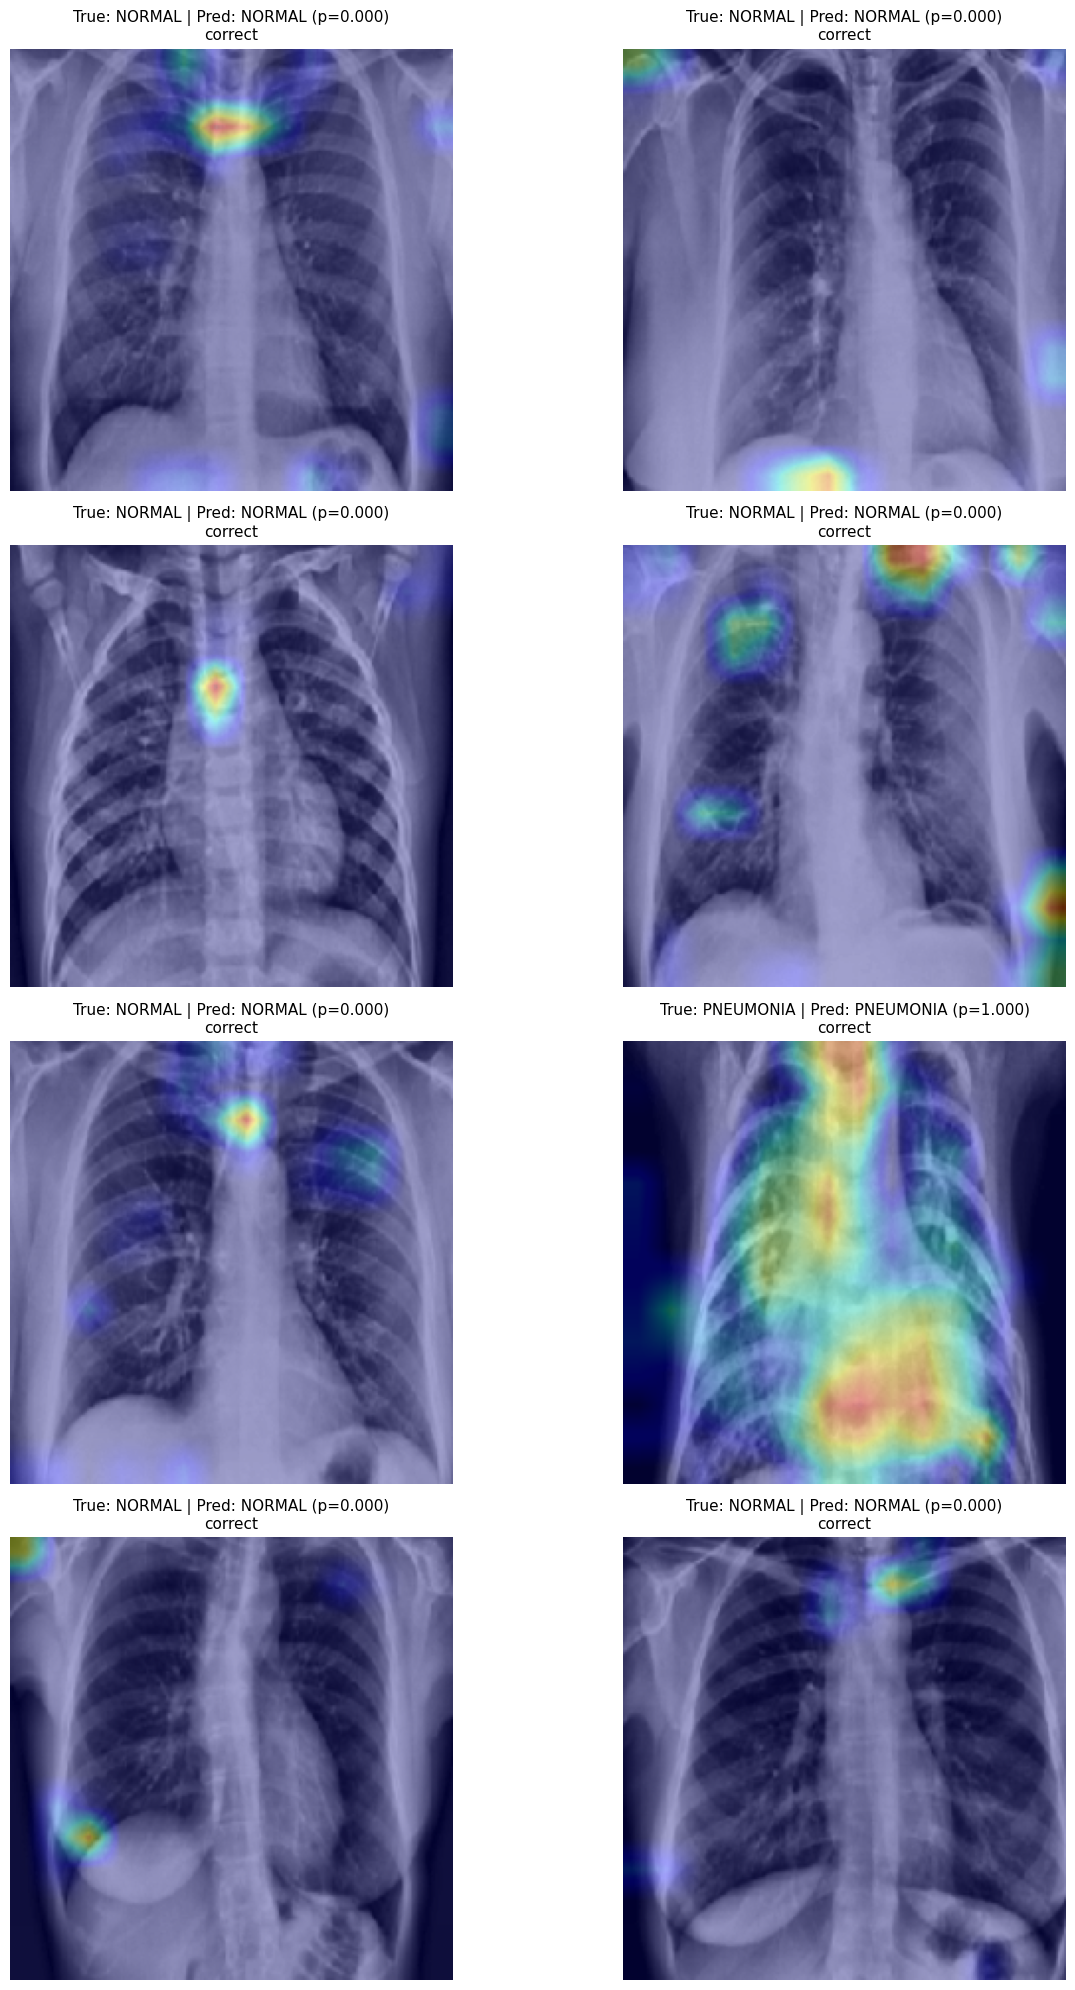

Saved Grad-CAM overlays to: /kaggle/working/figures/gradcam_vgg16_covid


In [24]:
def overlay_heatmap(img_rgb_01, heatmap, alpha=0.35):
    heatmap_tf      = tf.convert_to_tensor(heatmap[..., np.newaxis], dtype=tf.float32)
    heatmap_tf      = tf.image.resize(heatmap_tf, (img_rgb_01.shape[0], img_rgb_01.shape[1]))
    heatmap_resized = heatmap_tf.numpy().squeeze()
    colored         = plt.get_cmap("jet")(heatmap_resized)[:, :, :3]
    return np.clip((1 - alpha) * img_rgb_01 + alpha * colored, 0, 1)
 
def deprocess_vgg16_image(x):
    x = x.copy()
    x[..., 0] += 103.939
    x[..., 1] += 116.779
    x[..., 2] += 123.68
    x = x[..., ::-1]
    return np.clip(x, 0, 255) / 255.0
 
def gradcam_on_test_samples(model, test_gen, last_conv_layer_name,
                             n=8, threshold=0.5, seed=42,
                             save_dir="/kaggle/working/figures/gradcam_vgg16_covid"):
    rng = np.random.default_rng(seed)
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=0).ravel()
    y_true = test_gen.classes
    y_pred = (y_prob >= threshold).astype(int)
    idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
    class_names  = [idx_to_class[0], idx_to_class[1]]
    idxs = rng.choice(len(y_true), size=min(n, len(y_true)), replace=False)
    os.makedirs(save_dir, exist_ok=True)
 
    cols = 2
    rows = int(np.ceil(len(idxs) / cols))
    plt.figure(figsize=(cols * 7, rows * 5))
 
    for i, idx in enumerate(idxs, start=1):
        filepath = test_gen.filepaths[idx]
        pil_img  = tf.keras.utils.load_img(filepath, target_size=test_gen.target_size)
        img_arr  = tf.keras.utils.img_to_array(pil_img)
 
        img_for_model = crop_clahe(img_arr.copy())
        img_rgb_01    = deprocess_vgg16_image(img_for_model)
        img_batch     = np.expand_dims(img_for_model, axis=0)
 
        heatmap     = make_gradcam_heatmap(img_batch, model, last_conv_layer_name)
        overlay_img = overlay_heatmap(img_rgb_01, heatmap, alpha=0.35)
 
        true_label = y_true[idx]
        pred_label = y_pred[idx]
        prob       = y_prob[idx]
        correct    = (true_label == pred_label)
 
        title = (
            f"True: {class_names[true_label]} | Pred: {class_names[pred_label]} (p={prob:.3f})\n"
            f"{'correct' if correct else 'wrong'}"
        )
        plt.subplot(rows, cols, i)
        plt.imshow(overlay_img)
        plt.axis("off")
        plt.title(title, fontsize=11)
 
        out_name = f"gradcam_{i:02d}_idx{idx}_true{class_names[true_label]}_pred{class_names[pred_label]}_p{prob:.3f}.png"
        plt.imsave(os.path.join(save_dir, out_name), overlay_img)
 
    plt.tight_layout()
    plt.show()
    print("Saved Grad-CAM overlays to:", save_dir)
 
gradcam_on_test_samples(
    model=model,
    test_gen=test_gen,
    last_conv_layer_name=last_conv_name,
    n=8,
    threshold=0.5,
    seed=42
)